In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import warnings
import time

from sb_og_dirac import *

In [2]:
warnings.filterwarnings('ignore')
torch.manual_seed(123)

# 1. Load MNIST and map to [-1,1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
ds = datasets.FashionMNIST('./data', train=True, download=True, transform=transform)
loader = torch.utils.data.DataLoader(ds, batch_size=5000, shuffle=True)
Xdata = next(iter(loader))[0].view(-1, 28 * 28).numpy()

In [3]:
start_time = time.time()
sbg = SBG(T=0.5, N=200, Xdata=Xdata)

# 3. Batch generation with snapshots
B = 16
steps = [0, 25, 50, 75, 100, 125, 150, 200]  # 8 time points
snaps = sbg.sde_batch_with_snapshots(B, steps)

elapsed = time.time() - start_time
print(f"Total runtime: {elapsed:.2f} seconds")

Total runtime: 47.71 seconds


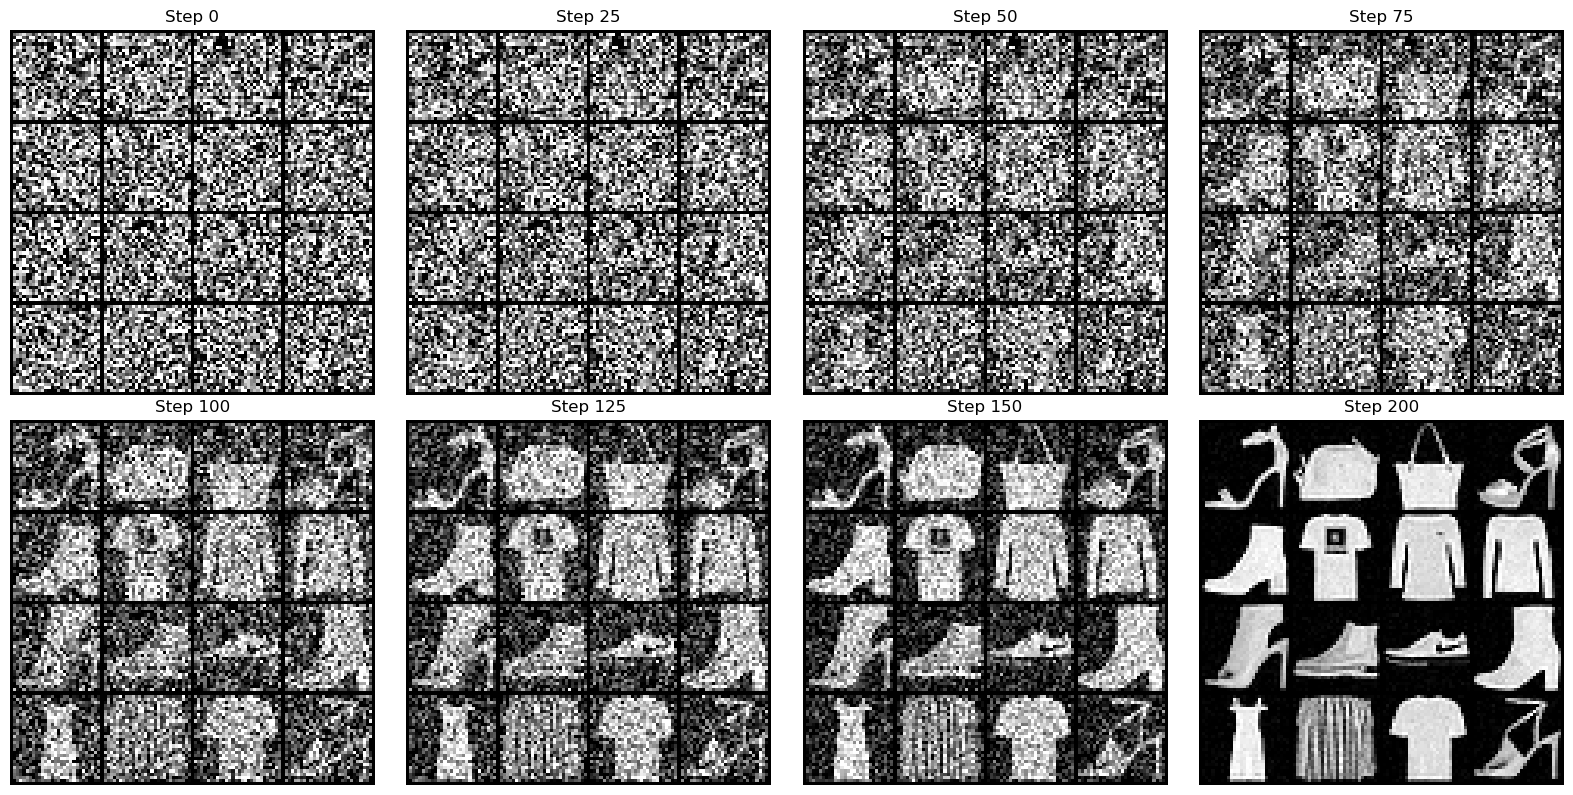

In [4]:
plt.figure(figsize=(16, 8))  # Adjust figure size for 2×4 layout
for i, step in enumerate(steps, 1):
    batch_img = (snaps[step] + 1) / 2  # Convert to [0,1]
    batch_img = np.clip(batch_img, 0, 1)
    tensor = torch.tensor(batch_img.reshape(-1, 1, 28, 28))
    grid = make_grid(tensor, nrow=4, normalize=False, padding=1)

    plt.subplot(2, 4, i)  # 2 rows, 4 columns
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray')
    plt.title(f"Step {step}")
    plt.axis('off')
plt.tight_layout()
#plt.savefig('fashion_minst.png')
